## Summary

This notebook generated thesis-ready visualizations for comparing baseline CNN, dynamic quantized TFLite CNN, and 50% magnitude-pruned CNN models. The figures compare detection performance, model size, and inference time across NSL-KDD and UNSW-NB15. These visualizations support the thesis analysis of the trade-off between intrusion detection accuracy and lightweight deployment efficiency.

In [8]:
figure_files = [
    FIGURES_DIR / "f1_score_comparison.png",
    FIGURES_DIR / "model_size_comparison.png",
    FIGURES_DIR / "inference_time_comparison.png",
    FIGURES_DIR / "detection_metrics_comparison.png"
]

for figure in figure_files:
    print(figure.name, figure.exists())
    

f1_score_comparison.png True
model_size_comparison.png True
inference_time_comparison.png True
detection_metrics_comparison.png True


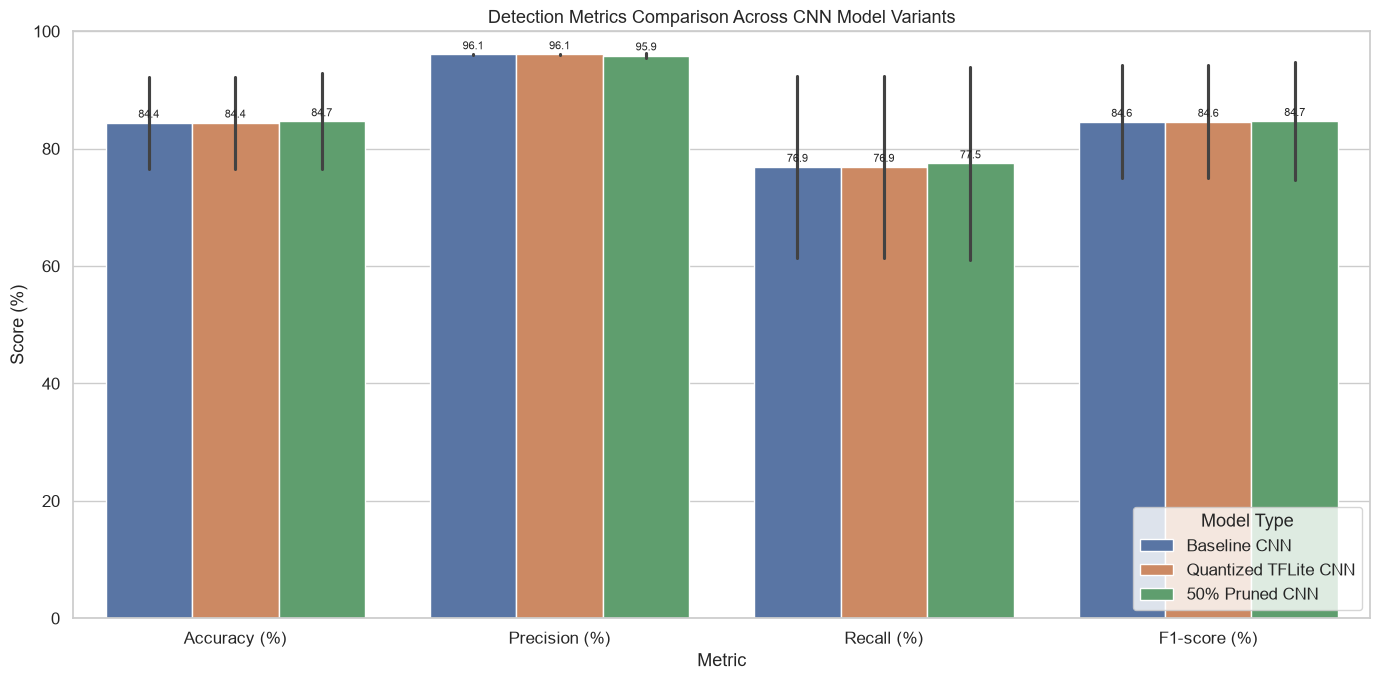

Saved figure: C:\Users\Admin\Desktop\Lightweight-IoT-IDS\figures\detection_metrics_comparison.png
Figure exists: True


In [7]:
metrics_long = plot_df.melt(
    id_vars=["Dataset", "Model Type"],
    value_vars=["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-score (%)"],
    var_name="Metric",
    value_name="Score (%)"
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score (%)",
    hue="Model Type"
)

ax.set_title("Detection Metrics Comparison Across CNN Model Variants")
ax.set_xlabel("Metric")
ax.set_ylabel("Score (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=2, fontsize=8)

plt.legend(title="Model Type", loc="lower right")
plt.tight_layout()

metrics_plot_path = FIGURES_DIR / "detection_metrics_comparison.png"
plt.savefig(metrics_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", metrics_plot_path)
print("Figure exists:", metrics_plot_path.exists())

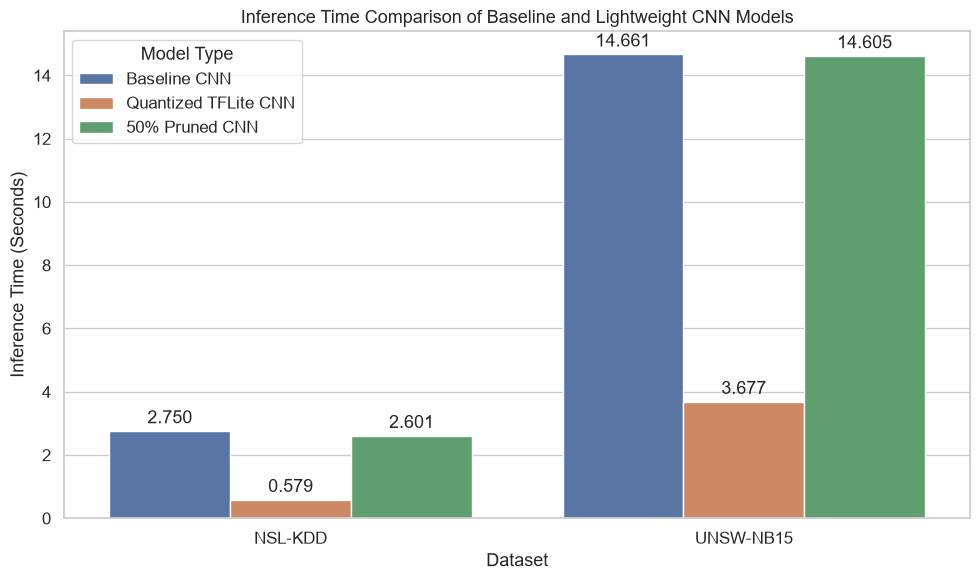

Saved figure: C:\Users\Admin\Desktop\Lightweight-IoT-IDS\figures\inference_time_comparison.png
Figure exists: True


In [6]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Inference Time Seconds",
    hue="Model Type"
)

ax.set_title("Inference Time Comparison of Baseline and Lightweight CNN Models")
ax.set_xlabel("Dataset")
ax.set_ylabel("Inference Time (Seconds)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.legend(title="Model Type", loc="upper left")
plt.tight_layout()

inference_plot_path = FIGURES_DIR / "inference_time_comparison.png"
plt.savefig(inference_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", inference_plot_path)
print("Figure exists:", inference_plot_path.exists())

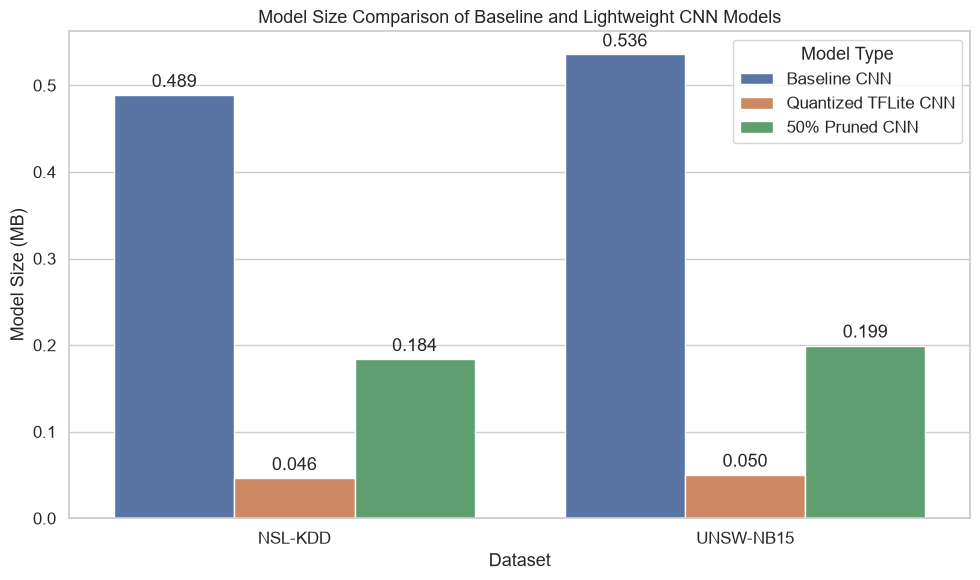

Saved figure: C:\Users\Admin\Desktop\Lightweight-IoT-IDS\figures\model_size_comparison.png
Figure exists: True


In [5]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="Dataset",
    y="Model Size MB",
    hue="Model Type"
)

ax.set_title("Model Size Comparison of Baseline and Lightweight CNN Models")
ax.set_xlabel("Dataset")
ax.set_ylabel("Model Size (MB)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.legend(title="Model Type", loc="upper right")
plt.tight_layout()

size_plot_path = FIGURES_DIR / "model_size_comparison.png"
plt.savefig(size_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", size_plot_path)
print("Figure exists:", size_plot_path.exists())

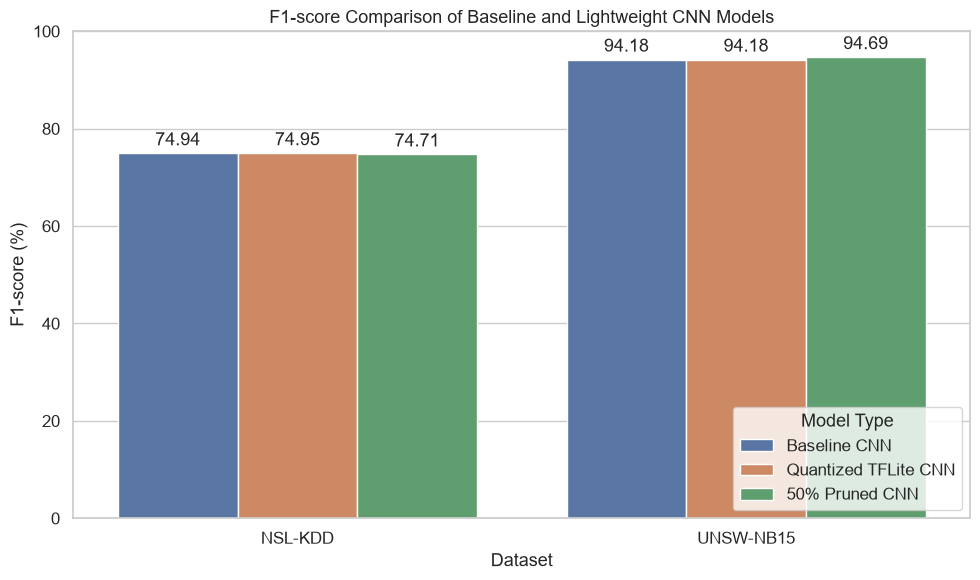

Saved figure: C:\Users\Admin\Desktop\Lightweight-IoT-IDS\figures\f1_score_comparison.png
Figure exists: True


In [4]:
sns.set_theme(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=plot_df,
    x="Dataset",
    y="F1-score (%)",
    hue="Model Type"
)

ax.set_title("F1-score Comparison of Baseline and Lightweight CNN Models")
ax.set_xlabel("Dataset")
ax.set_ylabel("F1-score (%)")
ax.set_ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.legend(title="Model Type", loc="lower right")
plt.tight_layout()

f1_plot_path = FIGURES_DIR / "f1_score_comparison.png"
plt.savefig(f1_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", f1_plot_path)
print("Figure exists:", f1_plot_path.exists())

In [3]:
plot_df = results.copy()

plot_df["Accuracy (%)"] = plot_df["Accuracy"] * 100
plot_df["Precision (%)"] = plot_df["Precision"] * 100
plot_df["Recall (%)"] = plot_df["Recall"] * 100
plot_df["F1-score (%)"] = plot_df["F1-score"] * 100

plot_df["Model Type"] = plot_df["Model"].replace({
    "Baseline CNN": "Baseline CNN",
    "Dynamic Quantized TFLite CNN": "Quantized TFLite CNN",
    "50% Magnitude Pruned CNN": "50% Pruned CNN"
})

display(plot_df[[
    "Dataset",
    "Model Type",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Inference Time Seconds",
    "Model Size MB"
]])

,Dataset,Model Type,Accuracy (%),Precision (%),Recall (%),F1-score (%),Inference Time Seconds,Model Size MB
0,NSL-KDD,Baseline CNN,76.605749,96.018507,61.450947,74.940606,2.750228,0.488823
1,UNSW-NB15,Baseline CNN,92.228857,96.100543,92.328705,94.176873,14.660965,0.535698
2,NSL-KDD,Quantized TFLite CNN,76.619056,96.042377,61.458739,74.953671,0.578795,0.046349
3,UNSW-NB15,Quantized TFLite CNN,92.229998,96.103828,92.327029,94.177579,3.677338,0.050255
4,NSL-KDD,50% Pruned CNN,76.477111,96.264438,61.045741,74.712698,2.601195,0.183807
5,UNSW-NB15,50% Pruned CNN,92.824268,95.466122,93.917430,94.685443,14.604850,0.199432


In [2]:
results = pd.read_csv(ALL_RESULTS_PATH)

print("Results shape:", results.shape)
display(results)

Results shape: (6, 10)


,Dataset,Model,Accuracy,Precision,Recall,F1-score,Training Time Seconds,Inference Time Seconds,Model Size MB,Sparsity
0,NSL-KDD,Baseline CNN,0.766057,0.960185,0.614509,0.749406,137.072274,2.750228,0.488823,NaN
1,UNSW-NB15,Baseline CNN,0.922289,0.961005,0.923287,0.941769,43.730621,14.660965,0.535698,NaN
2,NSL-KDD,Dynamic Quantized TFLite CNN,0.766191,0.960424,0.614587,0.749537,NaN,0.578795,0.046349,NaN
3,UNSW-NB15,Dynamic Quantized TFLite CNN,0.922300,0.961038,0.923270,0.941776,NaN,3.677338,0.050255,NaN
4,NSL-KDD,50% Magnitude Pruned CNN,0.764771,0.962644,0.610457,0.747127,NaN,2.601195,0.183807,0.5
5,UNSW-NB15,50% Magnitude Pruned CNN,0.928243,0.954661,0.939174,0.946854,NaN,14.604850,0.199432,0.5


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALL_RESULTS_PATH = RESULTS_DIR / "all_model_comparison_results.csv"

print("Results file exists:", ALL_RESULTS_PATH.exists())
print("Figures directory:", FIGURES_DIR)

Results file exists: True
Figures directory: C:\Users\Admin\Desktop\Lightweight-IoT-IDS\figures
